<a href="https://colab.research.google.com/github/pujisubarkah/replikasi_DAiSEE-Towards-User-Engagement-Recognition-in-the-Wild/blob/main/notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olgaparfenova/daisee")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'daisee' dataset.
Path to dataset files: /kaggle/input/daisee


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['DAiSEE']


In [ ]:
import os

daissee_path = os.path.join(path, 'DAiSEE')
print(os.listdir(daissee_path))

['Labels', 'DataSet', 'README.txt', 'GenderClips', 'hog.py', 'extractFrames.py']


In [ ]:
import os

dataset_path = os.path.join(daissee_path, 'DataSet')
print(os.listdir(dataset_path))

['Validation', 'Test.txt', 'Validation.txt', 'Train.txt', 'Test', 'Train']


In [ ]:
import os

# dataset_path is already defined from previous steps
# dataset_path = os.path.join(daissee_path, 'DataSet')

total_videos = 0

for split in ["Train", "Validation", "Test"]:
    split_path = os.path.join(dataset_path, split)

    count = 0
    if os.path.exists(split_path):
        for root, dirs, files in os.walk(split_path):
            for file in files:
                if file.endswith(".avi") or file.endswith(".mp4"):
                    count += 1

    print(f"{split}: {count} videos")
    total_videos += count

print(f"\nTotal videos: {total_videos}")

Train: 5482 videos
Validation: 1720 videos
Test: 1866 videos

Total videos: 9068


In [ ]:
import os

print(os.listdir(daissee_path))
print(os.listdir(os.path.join(daissee_path, "DataSet", "Train"))[:5])

['Labels', 'DataSet', 'README.txt', 'GenderClips', 'hog.py', 'extractFrames.py']
['205601', '110041', '200050', '110010', '181374']


# DAiSEE Dataset Exploration

Model Replication of

"DAiSEE: Towards User Engagement Recognition in the Wild"

Notebook 1

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams["figure.figsize"] = (12,6)

In [ ]:
DATASET_PATH = "/content/DAiSEE"

DATA_PATH = os.path.join(DATASET_PATH,"DataSet")
LABEL_PATH = os.path.join(DATASET_PATH,"Labels")

In [ ]:
print("Root Folder")
print(os.listdir(daissee_path))

Root Folder
['Labels', 'DataSet', 'README.txt', 'GenderClips', 'hog.py', 'extractFrames.py']


In [ ]:
import os

print(os.listdir(dataset_path))

['Validation', 'Test.txt', 'Validation.txt', 'Train.txt', 'Test', 'Train']


In [ ]:
TRAIN_PATH = os.path.join(dataset_path, "Train")

print(os.listdir(TRAIN_PATH)[:10])

['205601', '110041', '200050', '110010', '181374', '210061', '459999', '310072', '210059', '310081']


In [ ]:
TRAIN_PATH = os.path.join(dataset_path, "Train")

subjects = sorted([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

print("Jumlah Subject Train :", len(subjects))
print(subjects[:5])

Jumlah Subject Train : 70
['110001', '110002', '110004', '110005', '110006']


In [ ]:
VALIDATION_PATH = os.path.join(dataset_path, "Validation")
TEST_PATH = os.path.join(dataset_path, "Test")

train_subjects = len([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

validation_subjects = len([
    d for d in os.listdir(VALIDATION_PATH)
    if os.path.isdir(os.path.join(VALIDATION_PATH, d))
])

test_subjects = len([
    d for d in os.listdir(TEST_PATH)
    if os.path.isdir(os.path.join(TEST_PATH, d))
])

print(f"Train      : {train_subjects}")
print(f"Validation : {validation_subjects}")
print(f"Test       : {test_subjects}")
print(f"Total      : {train_subjects + validation_subjects + test_subjects}")

Train      : 70
Validation : 22
Test       : 21
Total      : 113


In [ ]:
def count_videos(split_path):
    total = 0
    if os.path.exists(split_path):
        for root, dirs, files in os.walk(split_path):
            for file in files:
                if file.endswith(".avi") or file.endswith(".mp4"):
                    total += 1
    return total

In [ ]:
train_videos = count_videos(TRAIN_PATH)
validation_videos = count_videos(VALIDATION_PATH)
test_videos = count_videos(TEST_PATH)

print("Train Videos      :", train_videos)
print("Validation Videos :", validation_videos)
print("Test Videos       :", test_videos)
print("Total Videos      :", train_videos + validation_videos + test_videos)

Train Videos      : 5482
Validation Videos : 1720
Test Videos       : 1866
Total Videos      : 9068


In [ ]:
LABEL_PATH = os.path.join(daissee_path, 'Labels')
print(os.listdir(LABEL_PATH))

['TrainLabels.csv', 'AllLabels.csv', 'TestLabels.csv', 'ValidationLabels.csv']


In [ ]:
train_labels = pd.read_csv(os.path.join(LABEL_PATH, "TrainLabels.csv"))
val_labels   = pd.read_csv(os.path.join(LABEL_PATH, "ValidationLabels.csv"))
test_labels  = pd.read_csv(os.path.join(LABEL_PATH, "TestLabels.csv"))

In [ ]:
train_labels.head()

,ClipID,Boredom,Engagement,Confusion,Frustration
0,1100011002.avi,0,2,0,0
1,1100011003.avi,0,2,0,0
2,1100011004.avi,0,3,0,0
3,1100011005.avi,0,3,0,0
4,1100011006.avi,0,3,0,0


In [ ]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5358 entries, 0 to 5357
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ClipID        5358 non-null   object
 1   Boredom       5358 non-null   int64 
 2   Engagement    5358 non-null   int64 
 3   Confusion     5358 non-null   int64 
 4   Frustration   5358 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 209.4+ KB


In [ ]:
#lihat nama kolom
train_labels.columns.tolist()

['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']

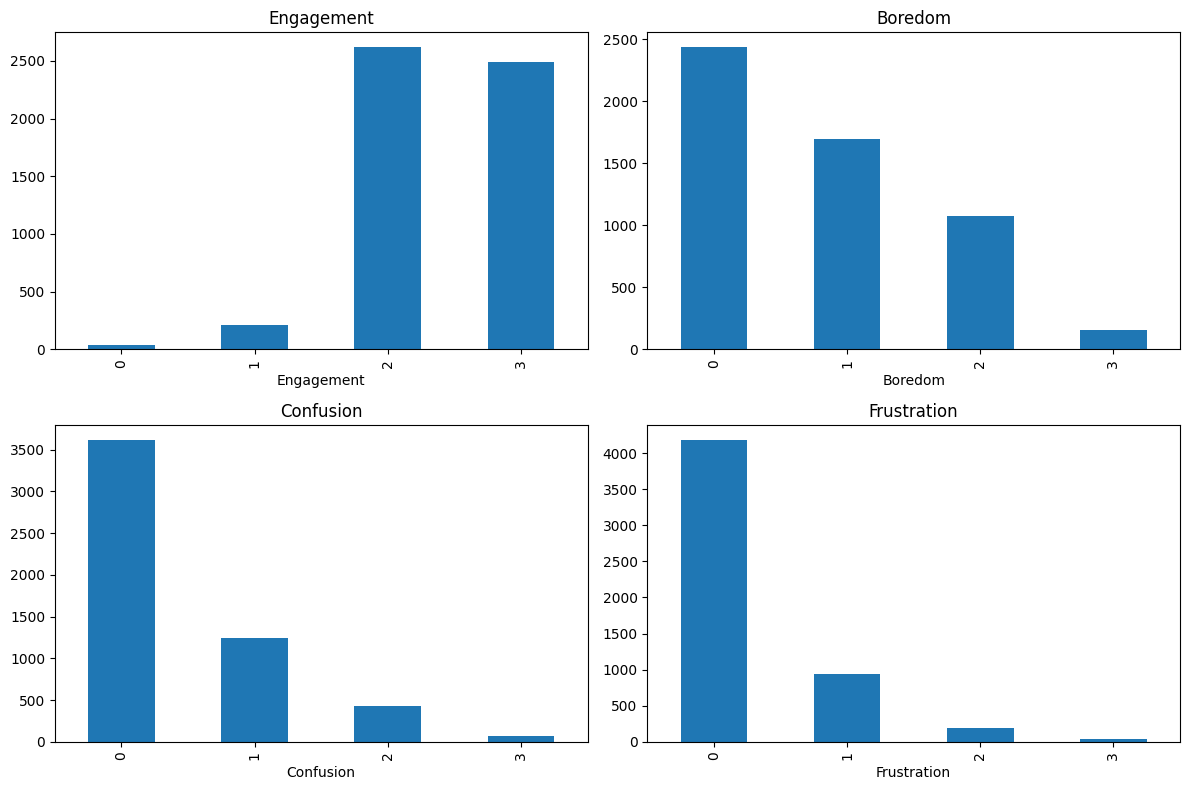

In [ ]:
#grafik engagement
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize=(12,8))

# Clean column names by stripping whitespace
train_labels.columns = train_labels.columns.str.strip()

columns = [
    "Engagement",
    "Boredom",
    "Confusion",
    "Frustration"
]

for i, col in enumerate(columns):

    r = i // 2
    c = i % 2

    train_labels[col].value_counts().sort_index().plot(
        kind="bar",
        ax=ax[r,c]
    )

    ax[r,c].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
#Sekarang kita lihat isi satu video.
subject = "110001"

subject_path = os.path.join(TRAIN_PATH, subject)

print(subject_path)


/kaggle/input/daisee/DAiSEE/DataSet/Train/110001


In [ ]:
clips = sorted(os.listdir(subject_path))

print(clips[:10])

['1100011002', '1100011003', '1100011004', '1100011005', '1100011006', '1100011007', '1100011008', '1100011009', '1100011010', '1100011011']


In [ ]:
clip = clips[0]

clip_folder = os.path.join(subject_path, clip)

print(clip_folder)

/kaggle/input/daisee/DAiSEE/DataSet/Train/110001/1100011002


In [ ]:
print(os.listdir(clip_folder))

['1100011002.avi']


### Displaying a video frame

Now, let's read the video file and display its first frame to confirm it's accessible and to get an idea of the video content. We will use `opencv-python` (`cv2`) for video processing and `matplotlib` for displaying the frame.

Attempting to open video: /kaggle/input/daisee/DAiSEE/DataSet/Train/110001/1100011002/1100011002.avi
Does path exist? True
Is path a file? True


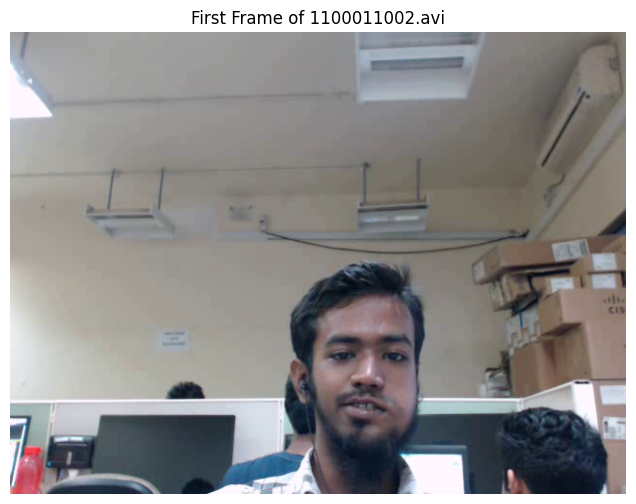

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Construct the full path to the video file
# We know from the previous cell that the video file is inside clip_folder
video_filename = os.listdir(clip_folder)[0] # e.g., '1100011002.avi'
video_path = os.path.join(clip_folder, video_filename)

print(f"Attempting to open video: {video_path}")

# --- Diagnostic checks for the video path ---
print(f"Does path exist? {os.path.exists(video_path)}")
print(f"Is path a file? {os.path.isfile(video_path)}")
# ------------------------------------------

# Open the video file
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
else:
    # Read the first frame
    ret, frame = cap.read()

    if ret:
        # Convert the frame from BGR (OpenCV default) to RGB (Matplotlib default)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Display the frame
        plt.imshow(frame_rgb)
        plt.title(f"First Frame of {video_filename}")
        plt.axis('off') # Hide axes ticks and labels
        plt.show()
    else:
        print("Error: Could not read first frame.")

    # Release the video capture object
    cap.release()


In [ ]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Video gagal dibuka!")
else:
    print("Video berhasil dibuka!")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Ensure fps is not zero before division
    if fps == 0:
        print(f"Warning: FPS is 0 for video {video_path}. Cannot calculate duration.")
        duration = 0.0
    else:
        duration = frame_count / fps

    print(f"Frame      : {frame_count}")
    print(f"FPS        : {fps}")
    print(f"Resolution : {width} x {height}")
    print(f"Duration   : {duration:.2f} detik")

cap.release()

Video berhasil dibuka!
Frame      : 300
FPS        : 30.0
Resolution : 640 x 480
Duration   : 10.00 detik


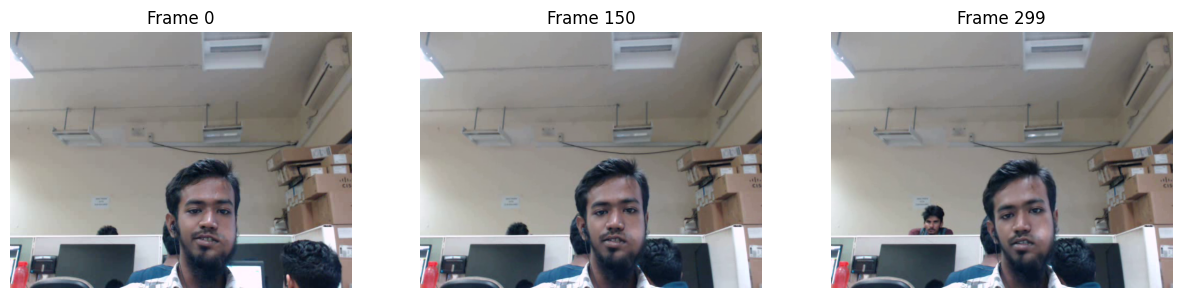

In [ ]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)

frame_positions = [
    0,
    frame_count // 2,
    frame_count - 1
]

fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, pos in zip(axes, frame_positions):

    cap.set(cv2.CAP_PROP_POS_FRAMES, pos)

    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(frame)
        ax.set_title(f"Frame {pos}")
        ax.axis("off")

cap.release()

plt.show()

In [ ]:
summary = pd.DataFrame({
    "Information": [
        "Train Subjects",
        "Validation Subjects",
        "Test Subjects",
        "Total Subjects",
        "Train Videos",
        "Validation Videos",
        "Test Videos",
        "Total Videos",
        "Frame per Video",
        "FPS",
        "Resolution"
    ],
    "Value": [
        train_subjects,
        validation_subjects,
        test_subjects,
        train_subjects + validation_subjects + test_subjects,
        train_videos,
        validation_videos,
        test_videos,
        train_videos + validation_videos + test_videos,
        frame_count,
        fps,
        f"{width} × {height}"
    ]
})

summary

,Information,Value
0,Train Subjects,70
1,Validation Subjects,22
2,Test Subjects,21
3,Total Subjects,113
4,Train Videos,5482
5,Validation Videos,1720
6,Test Videos,1866
7,Total Videos,9068
8,Frame per Video,300
9,FPS,30.0
